In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import lsq_linear
import pandas as pd
from scipy.linalg import lstsq
from sklearn.model_selection import train_test_split
import cvxpy as cp

In [17]:
def train(q_hp, delta_T_i, delta_T_a, q_solar, idx_night, delta_t):
    N = len(delta_T_i)
    
    # Expression
    X1 = delta_T_a*delta_t
    X2 = q_hp
    X3 = idx_night
    X4 = q_solar 
    
    Y_n = delta_T_i
     
    X_n = np.column_stack([X1, X2, X3, X4])
    lb = [-np.inf, -np.inf, 0.0, 0.0]
    ub = [ np.inf,  np.inf, np.inf, np.inf]

    res = lsq_linear(X_n, Y_n, bounds=(lb, ub))

    theta_n = res.x
    residuals_n = res.cost * 2   # lsq_linear reports 1/2 ||r||^2

    # recover parameters
    alpha, beta, gamma, epsilon = theta_n   # [1/(C·R), 1/C, w_n/C]
    C     = 1.0 / beta
    R_a   = beta / alpha
    w_n   = gamma * C
    eta_s   = epsilon * C
    rmse_n  = np.sqrt(residuals_n / len(Y_n))

    return C, R_a, w_n, eta_s, rmse_n

In [18]:
df_data = pd.read_parquet("training_data/initial_dataset.parquet")
df_train_detached = pd.read_parquet(
    "training_data/data_detached_with_weather.parquet")
type(df_data)
type(df_train_detached)
df_train_detached

,Property_ID,Timestamp,half-hour,Boiler_Energy_Output,Circulation_Pump_Energy_Consumed,Heat_Pump_Energy_Output,Whole_System_Energy_Consumed,External_Air_Temperature,Heat_Pump_Heating_Flow_Temperature,Heat_Pump_Return_Temperature,...,Postcode,Time,Temperature,FeelsLike,Humidity,Dew,Precipitation,SolarRadiation,SolarEnergy,Windspeed
0,EOH0279,2020-10-26 00:00:00,00:00:00,NaN,0.000,0.000,0.008,9.38,23.14,23.35,...,EH22,00:00:00,8.90,6.10,79.75,5.6,0.154,0.0,0.0,19.30
1,EOH1703,2020-10-26 00:00:00,00:00:00,NaN,0.013,0.242,0.078,7.08,25.04,24.04,...,NE15,00:00:00,7.00,4.30,81.71,4.1,0.170,0.0,0.0,14.30
2,EOH1703,2020-10-26 00:30:00,00:30:00,NaN,0.029,0.622,0.212,6.83,25.43,24.23,...,NE15,00:30:00,6.95,4.05,81.93,4.1,0.085,0.0,0.0,15.85
3,EOH0279,2020-10-26 00:30:00,00:30:00,NaN,0.000,0.000,0.019,9.33,22.54,22.80,...,EH22,00:30:00,8.85,6.30,79.94,5.6,0.077,0.0,0.0,17.00
4,EOH0279,2020-10-26 01:00:00,01:00:00,NaN,0.000,2.730,0.967,9.21,35.27,30.93,...,EH22,01:00:00,8.80,6.50,80.13,5.6,0.000,0.0,0.0,14.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505054,EOH3154,2023-09-29 00:00:00,00:00:00,NaN,0.000,44801.768,14989.282,12.44,18.87,50.46,...,EH15,00:00:00,12.80,12.80,90.62,11.3,0.333,0.0,0.0,16.00
505055,EOH1637,2023-09-29 00:00:00,00:00:00,NaN,203.311,43996.381,13830.005,12.17,16.70,16.53,...,PH7,00:00:00,13.20,13.20,86.43,11.0,0.004,0.0,0.0,17.00
505056,EOH2329,2023-09-29 00:00:00,00:00:00,NaN,31.139,14128.100,5775.602,12.44,24.80,26.31,...,EH4,00:00:00,12.90,12.90,90.75,11.4,0.378,0.0,0.0,15.00
505057,EOH2675,2023-09-29 00:00:00,00:00:00,NaN,212.928,59675.471,19247.887,12.44,14.82,14.85,...,EH9,00:00:00,13.00,13.00,93.04,11.9,0.024,0.0,0.0,24.30


In [19]:
unique_ids = df_train_detached["Property_ID"].unique()

df_house = pd.read_csv('training_data/home_characteristics.csv')

# List of columns to check for missingness
cols = [
    "Bedrooms", "Floor_Height", "Habitable_Rooms", "House_Age",
    "House_Form", "No_Storeys", "No_Underfloor",
    "Total_Floor_Area", "Wall_Type", "MCS_DHWAnnual","HP_Size_kW",
    "HP_Installed", "House_SAP"
]

df_house_train = {}
for id_use in unique_ids:
    df_house_train[id_use] = df_house[df_house["Property_ID"] == id_use]

In [20]:
missing_counts = df_house[df_house["Property_ID"].isin(unique_ids)][["Floor_Height", "Total_Floor_Area"]].isna().sum()
print(missing_counts)


Floor_Height        0
Total_Floor_Area    0
dtype: int64


In [21]:
trained_params = pd.DataFrame(index=["Floor Area", "No_Storeys", "Wall_Type",
                                     "HP_Type", "House_SAP",
                                     "C", "R_a", "w_s", "w_n",
                                     "rmse"])

df_single = df_train_detached[df_train_detached["Property_ID"] == id_use].copy()
df_single = df_single.set_index('Timestamp')

#time range
t_start = pd.to_datetime("2022 01 01 00:00:00")
t_mid_end = pd.to_datetime("2022 5 31 23:59:59")
t_mid_start = pd.to_datetime("2022 08 31 00:00:00")
t_end = pd.to_datetime("2022 3 31 23:59:59")
df_index = df_single[df_single.index >= t_start]
df_index = df_index[df_index.index <= t_end]
#df_index = df_index[
#    (df_index.index <= t_mid_end) | (df_index.index >= t_mid_start)]

# Create time index for q_hat arrays
time_index = df_index.index[:-1]
df_q_id = pd.DataFrame(index=time_index)

for id_use in unique_ids:
    wall = df_house_train[id_use].Wall_Type.to_string()
    storeys = df_house_train[id_use].No_Storeys.to_string()
    floor_area = df_house_train[id_use].Total_Floor_Area.to_string()
    hp_type = df_house_train[id_use].HP_Installed.to_string()
    house_sap = df_house_train[id_use].House_SAP.to_string()

    df_single = df_train_detached[
        df_train_detached["Property_ID"] == id_use].copy()

    #re-adjust Heat Pump Diff and add temp differences
    df_single["Heat_Pump_Energy_Output_Diff"] = df_single[
        "Heat_Pump_Energy_Output"].diff()
    df_single["Internal_Temperature_Diff"] = df_single[
        "Internal_Air_Temperature"].diff()
    df_single["Internal_Ambient_Temperature_Diff"] = \
        (df_single["External_Air_Temperature"] -
         df_single["Internal_Air_Temperature"])

    # 1. Drop columns with almost all missing data (e.g., more than 90% missing)
    threshold = 0.1 * len(df_single)
    df_single_cleaned = df_single.dropna(axis=1, thresh=threshold)
    #print("Columns dropped due to high missing values:")
    #print(df_single.columns.difference(df_single_cleaned.columns).tolist())

    df_single = df_single_cleaned

    #print("\nColumns remaining after dropping highly missing columns:")
    #print(df_single.columns.tolist())

    df_single = df_single.set_index('Timestamp')
    df_single = df_single.sort_index()

    # Apply interpolation with a limit of 4 (for 2 hours of half-hourly data)
    numeric_cols = df_single.select_dtypes(include=['number']).columns
    df_single_numeric_interpolated = df_single[numeric_cols].interpolate(
        method='time', limit=4, limit_direction='both')

    df_single_interpolated = df_single.copy()
    df_single_interpolated[numeric_cols] = df_single_numeric_interpolated

    # After interpolation, drop rows that still contain NaN values (meaning they were missing for > 2 hours)
    initial_rows = len(df_single_interpolated)
    df_single_processed = df_single_interpolated.dropna()
    rows_dropped_after_interpolation = initial_rows - len(df_single_processed)

    #print(f"\nNumber of rows dropped after handling NA values (missing for >
    # 2 hours): {rows_dropped_after_interpolation}")

    # ------ Prepare Training Data ----------
    df_heating_single = df_single_processed.copy()

    df_heating_annual = df_heating_single[df_heating_single.index >= t_start]
    df_heating_annual = df_heating_annual[df_heating_annual.index <= t_end]
    #df_heating_annual = df_heating_annual[
    #    (df_heating_annual.index <= t_mid_end) | (df_heating_annual
    #                                              .index >= t_mid_start)]
    
        # Extract hour from Timestamp
    df_heating_annual_night = df_heating_annual.copy()
    df_heating_annual_night['Hour'] = df_heating_annual.index.hour
    
    # Define night and day conditions
    # Condition 1: Time is between 10 PM and 6 AM
    night_time_condition = (df_heating_annual_night['Hour'] >= 20) | \
                           (df_heating_annual_night['Hour'] < 6)
    
    # Condition 2: Solar Irradiation is 0 (assuming 'SolarRadiation' is the correct column name)
    if 'SolarRadiation' in df_heating_annual_night.columns:
        night_solar_condition = (df_heating_annual_night['SolarRadiation'] == 0)
        df_heating_annual_night['is_night'] = night_time_condition & night_solar_condition
    else:
        print("\nWarning: 'SolarRadiation' column not found after preprocessing. Cannot use it for night/day split.")
        df_heating_annual_night['is_night'] = night_time_condition # Fallback to just time condition    


    t_step = 30  # minutes
    delta_t = t_step / 60

    #Night data

    T_a = (df_heating_annual_night["External_Air_Temperature"].iloc[:-1]
              .reset_index
           (drop=True).to_numpy())
    T_i = (df_heating_annual_night["Internal_Air_Temperature"].iloc[:-1].reset_index
           (drop=True).to_numpy())
    delta_T_a = (
        df_heating_annual_night["Internal_Ambient_Temperature_Diff"].iloc[:-1]
        .reset_index(drop=True).to_numpy())
    delta_T_i = (df_heating_annual_night["Internal_Temperature_Diff"].iloc[1:]
                 .reset_index(drop=True).to_numpy() / delta_t)
    q_hp = (df_heating_annual_night["Heat_Pump_Energy_Output_Diff"].iloc[:-1]
            .reset_index(drop=True).to_numpy())
    q_solar = (df_heating_annual_night["SolarRadiation"].iloc[:-1].reset_index
               (drop=True).to_numpy())
    v_wind = (df_heating_annual_night["Windspeed"].iloc[:-1].reset_index(drop=True)
              .to_numpy())

    idx_night = df_heating_annual_night['is_night'].astype(int).iloc[:-1].to_numpy()
        
    # Create time index for in the loop q_hat arrays
    time_index = df_heating_annual.index[:-1]
    df_q_results = pd.DataFrame(index=time_index)

    
    C,R_a,w_n,eta_s, rmse =  train(q_hp, delta_T_i, delta_T_a, q_solar, 
                                     idx_night, delta_t)

    w_s = eta_s
    
    trained_params[id_use] = [floor_area, storeys, wall, hp_type, house_sap, 
                              C,R_a,eta_s,w_n,rmse]
    
    

In [22]:
df_heating_annual_night['is_night'].astype(int)

Timestamp
2022-01-01 00:00:00    1
2022-01-01 00:30:00    1
2022-01-01 01:00:00    1
2022-01-01 01:30:00    1
2022-01-01 02:00:00    1
                      ..
2022-03-31 21:30:00    1
2022-03-31 22:00:00    1
2022-03-31 22:30:00    1
2022-03-31 23:00:00    1
2022-03-31 23:30:00    1
Name: is_night, Length: 4320, dtype: int64

In [23]:
idx_night = df_heating_annual_night['is_night'].astype(int).iloc[:-1].to_numpy()
idx_night

array([1, 1, 1, ..., 1, 1, 1], shape=(4319,))

In [24]:
trained_params.to_csv("trained_params_lin_regres_v1.csv", index=True)
trained_params


,EOH0279,EOH1703,EOH1485,EOH0546,EOH2329,EOH2675,EOH3154,EOH0413,EOH1637,EOH3196
Floor Area,2066 172.33,2381 91.0,1569 130.12,1692 107.51,585 109.54,1156 135.55,1149 119.44,318 106.36,736 111.84,76 107.27
No_Storeys,2066 2.0,2381 2.0,1569 2.0,1692 1.0,585 1.0,1156 2.0,1149 1.0,318 2.0,736 2.0,76 2.0
Wall_Type,2066 Cavity_Insulated,2381 Cavity_Insulated,1569 Cavity_Insulated,1692 Cavity_Insulated,585 Cavity_Insulated,1156 Cavity_Insulated,1149 Cavity_Insulated,318 Cavity_Insulated,736 Cavity_Insulated,76 Cavity_No_insulation
HP_Type,2066 ASHP,2381 ASHP,1569 HT_ASHP,1692 ASHP,585 ASHP,1156 HT_ASHP,1149 HT_ASHP,318 Hybrid,736 HT_ASHP,76 ASHP
House_SAP,2066 A,2381 NaN,1569 C,1692 C,585 C,1156 E,1149 D,318 D,736 C,76 D
C,4.124462,2.598379,5.79519,6.131975,2.692357,6.938584,4.735256,3.071832,4.670125,4.405094
R_a,5.216131,6.552935,5.101451,5.745694,15.839978,3.085674,3.895851,7.082721,5.463962,5.591236
w_s,0.000538,0.000716,0.00188,0.004546,0.000231,0.001891,0.000874,0.002747,0.000403,0.000899
w_n,0.0,0.0,0.0,0.0,0.0,0.087884,0.0,0.0,0.0,0.0
rmse,0.187437,0.353578,0.283303,0.24128,0.354715,0.245243,0.202373,0.393568,0.3346,0.248947


In [25]:
for id_use in df_house_train:
    print(df_house_train[id_use].House_SAP)
    print(df_house_train[id_use].HP_Installed)

2066    A
Name: House_SAP, dtype: object
2066    ASHP
Name: HP_Installed, dtype: object
2381    NaN
Name: House_SAP, dtype: object
2381    ASHP
Name: HP_Installed, dtype: object
1569    C
Name: House_SAP, dtype: object
1569    HT_ASHP
Name: HP_Installed, dtype: object
1692    C
Name: House_SAP, dtype: object
1692    ASHP
Name: HP_Installed, dtype: object
585    C
Name: House_SAP, dtype: object
585    ASHP
Name: HP_Installed, dtype: object
1156    E
Name: House_SAP, dtype: object
1156    HT_ASHP
Name: HP_Installed, dtype: object
1149    D
Name: House_SAP, dtype: object
1149    HT_ASHP
Name: HP_Installed, dtype: object
318    D
Name: House_SAP, dtype: object
318    Hybrid
Name: HP_Installed, dtype: object
736    C
Name: House_SAP, dtype: object
736    HT_ASHP
Name: HP_Installed, dtype: object
76    D
Name: House_SAP, dtype: object
76    ASHP
Name: HP_Installed, dtype: object


RMSE of q_hp: 0.6077266811958005


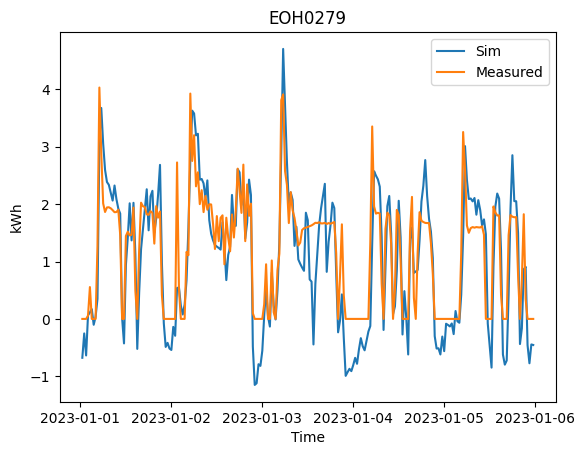

RMSE of q_hp: 0.9958601038156043


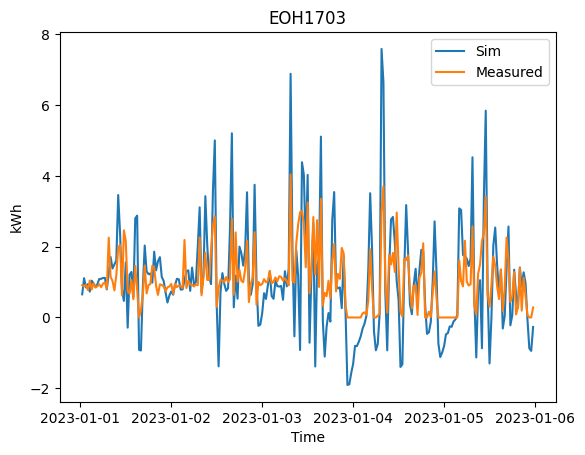

RMSE of q_hp: 1.8975444099788656


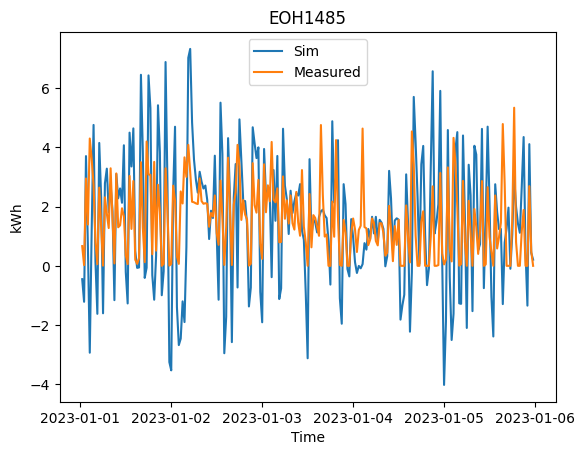

RMSE of q_hp: 1.4916711831957326


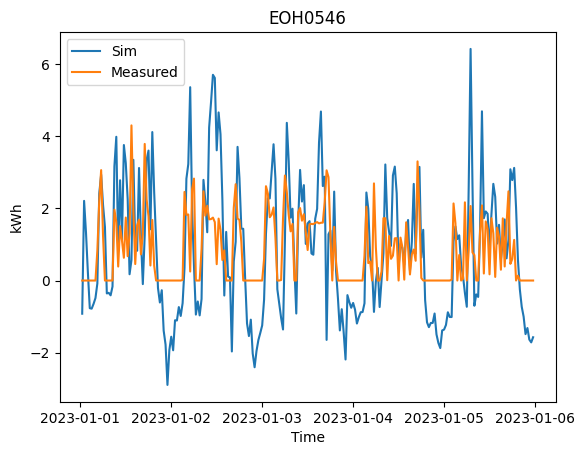

RMSE of q_hp: 1.0360676839377272


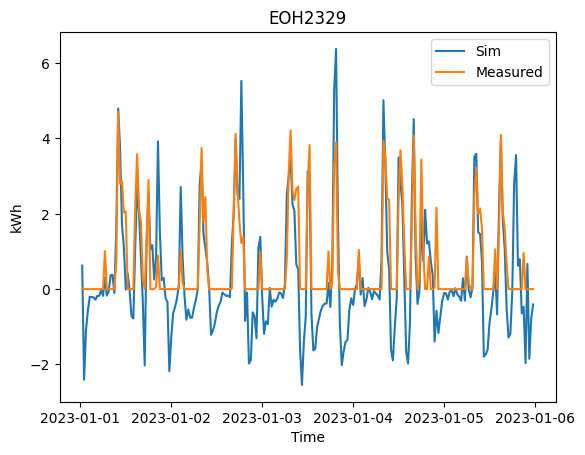

RMSE of q_hp: 1.4366785259750605


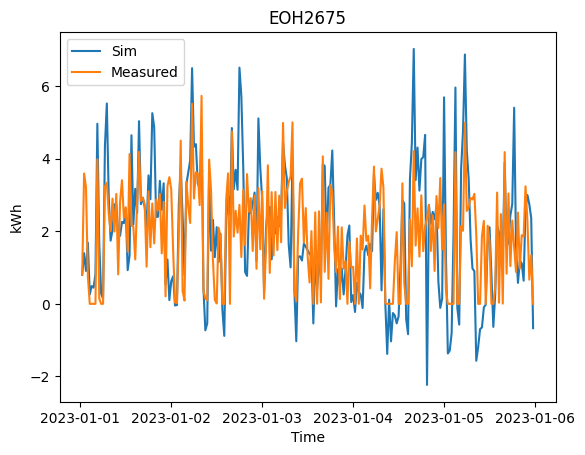

RMSE of q_hp: 0.845220404822159


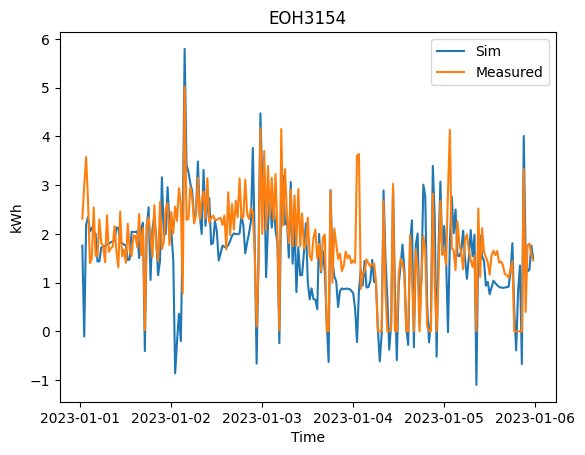

RMSE of q_hp: 0.8841370437056716


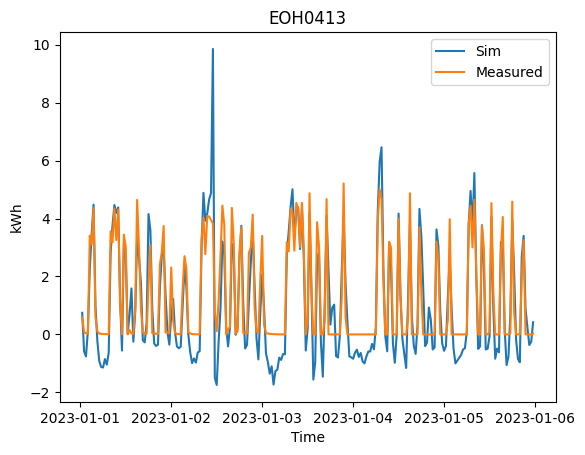

RMSE of q_hp: 1.6721717288633566


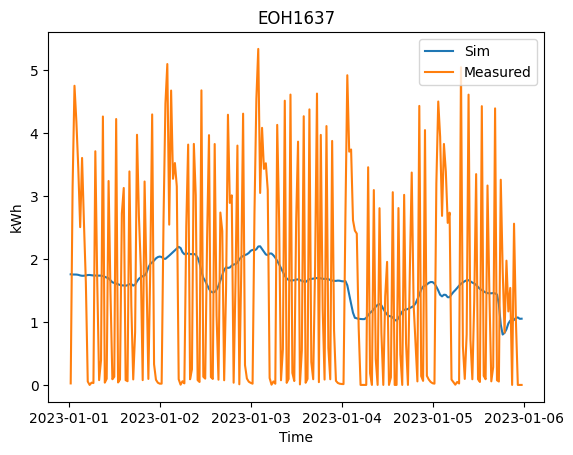

RMSE of q_hp: 1.1379510953710477


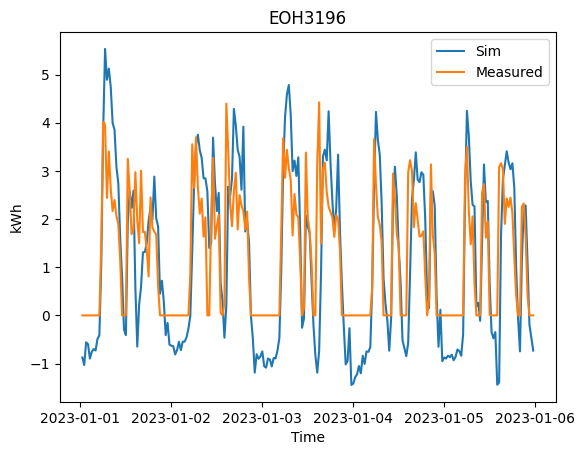

In [26]:
# ------- Look at heat supply performance in validation data ------

for id_use in unique_ids:
    df_id = trained_params[id_use].copy()
    C = df_id.C
    R_a = df_id.R_a
    w_s= df_id.w_s
    w_n = df_id.w_n
    
    
    df_single = df_train_detached[df_train_detached["Property_ID"] == id_use].copy()
    
    #re-adjust Heat Pump Diff and add temp differences
    df_single["Heat_Pump_Energy_Output_Diff"] = df_single["Heat_Pump_Energy_Output"].diff()
    df_single["Internal_Temperature_Diff"] = df_single["Internal_Air_Temperature"].diff()
    df_single["Internal_Ambient_Temperature_Diff"] = \
        (df_single["External_Air_Temperature"] - 
         df_single["Internal_Air_Temperature"])
    
    # 1. Drop columns with almost all missing data (e.g., more than 90% missing)
    threshold = 0.90 * len(df_single)
    df_single_cleaned = df_single.dropna(axis=1, thresh=threshold)
    #print("Columns dropped due to high missing values:")
    #print(df_single.columns.difference(df_single_cleaned.columns).tolist())
    
    df_single = df_single_cleaned
    
    #print("\nColumns remaining after dropping highly missing columns:")
    #print(df_single.columns.tolist())
    
    # 2. Handle missing values: Interpolate if missing for up to 2 hours (4 half-hour intervals), else drop rows
    df_single = df_single.set_index('Timestamp')
    df_single = df_single.sort_index()
    
    # Apply interpolation with a limit of 4 (for 2 hours of half-hourly data)
    numeric_cols = df_single.select_dtypes(include=['number']).columns
    df_single_numeric_interpolated = df_single[numeric_cols].interpolate(method='time', limit=4, limit_direction='both')
    
    df_single_interpolated = df_single.copy() 
    df_single_interpolated[numeric_cols] = df_single_numeric_interpolated
    
    # After interpolation, drop rows that still contain NaN values (meaning they were missing for > 2 hours)
    initial_rows = len(df_single_interpolated)
    df_single_processed = df_single_interpolated.dropna()
    rows_dropped_after_interpolation = initial_rows - len(df_single_processed)
    
    #print(f"\nNumber of rows dropped after handling NA values (missing for >
    # 2 hours): {rows_dropped_after_interpolation}")
    
    # -----EXTRACT SUMMER DATA -------# 
    df_heating_single = df_single_processed.copy()
    
    t_start = pd.to_datetime("2023 01 01 00:00:00")
    t_end = pd.to_datetime("2023 01 05 23:59:00")
    df_q_opt = df_q_results[(df_q_results.index>=t_start) & (df_q_results.index<=t_end)]
    df_heating_val = df_heating_single[df_heating_single.index>=t_start]
    df_heating_val = df_heating_val[df_heating_val.index<=t_end]
    
    # make sure you have an Hour column
    df_heating_val = df_heating_val.assign(Hour=df_heating_val.index.hour)
    
    # define night‑time & zero‑solar conditions
    night_time = (df_heating_val['Hour'] >= 22) | (df_heating_val['Hour'] < 6)
    zero_solar = (df_heating_val['SolarRadiation'] == 0)
    
    # vectorized assignment of w
    df_heating_val['w'] = np.where(night_time & zero_solar, w_n, 0.0)
    
    w = df_heating_val['w'].iloc[:-1].reset_index(drop=True).to_numpy()
    
    T_a_val = (df_heating_val["External_Air_Temperature"].iloc[:-1].reset_index
           (drop=True).to_numpy()) 
    T_i_val = (df_heating_val["Internal_Air_Temperature"].iloc[:-1].reset_index
           (drop=True).to_numpy()) 
    delta_T_a_val = (df_heating_val["Internal_Ambient_Temperature_Diff"].iloc[:-1]
                 .reset_index(drop=True).to_numpy()) 
    delta_T_i_val = (df_heating_val["Internal_Temperature_Diff"].iloc[1:]
                 .reset_index(drop=True).to_numpy() / delta_t) 
    q_hp_val = (df_heating_val["Heat_Pump_Energy_Output_Diff"].iloc[:-1]
            .reset_index(drop=True).to_numpy()) 
    q_solar_val = (df_heating_val["SolarRadiation"].iloc[:-1].reset_index
               (drop=True).to_numpy()) 
    v_wind_val = (df_heating_val["Windspeed"].iloc[:-1].reset_index(drop=True)
              .to_numpy()) 
    
    
    
    q_hat_sim = (delta_T_i_val * C -  delta_T_a_val / R_a * delta_t  - w_s *  
            q_solar_val  - w * np.ones(len(T_a_val), )* delta_t )
    
    e_q = q_hat_sim - q_hp_val
    rmse_q_val = np.sqrt(np.mean(e_q**2))
    print(f"RMSE of q_hp: {rmse_q_val}")
    
    plt.plot(df_heating_val.index[1:],q_hat_sim, label = "Sim")
    plt.plot(df_heating_val.index[1:], q_hp_val, label = "Measured")
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("kWh")
    plt.title(f"{id_use}")
    plt.show()

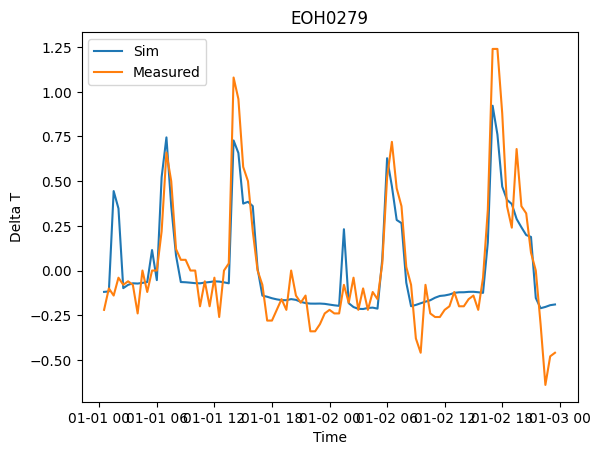

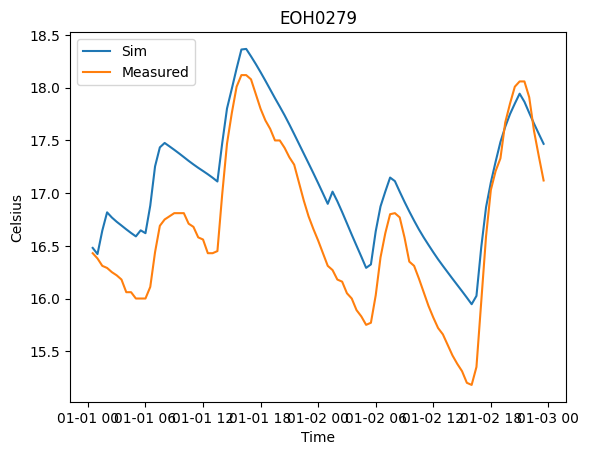

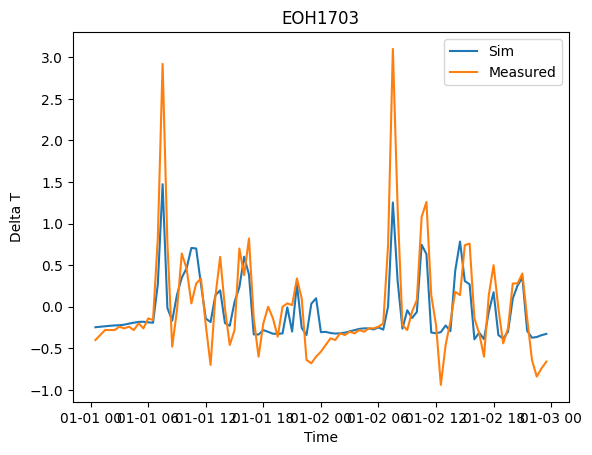

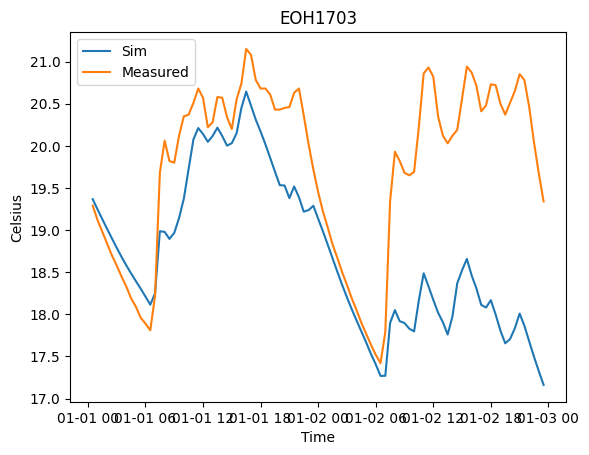

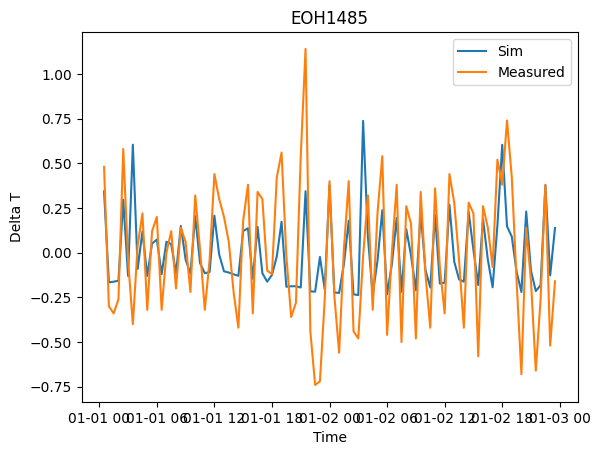

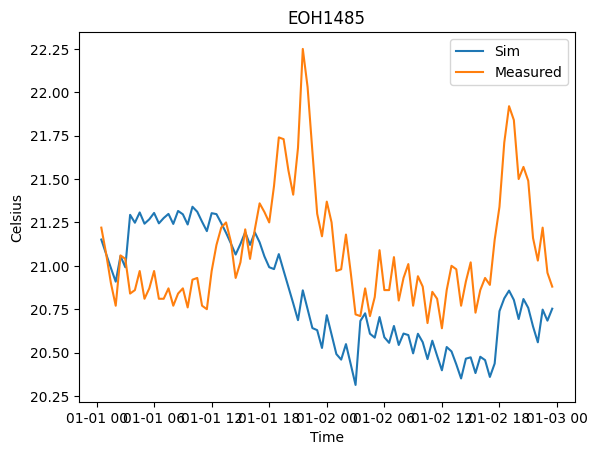

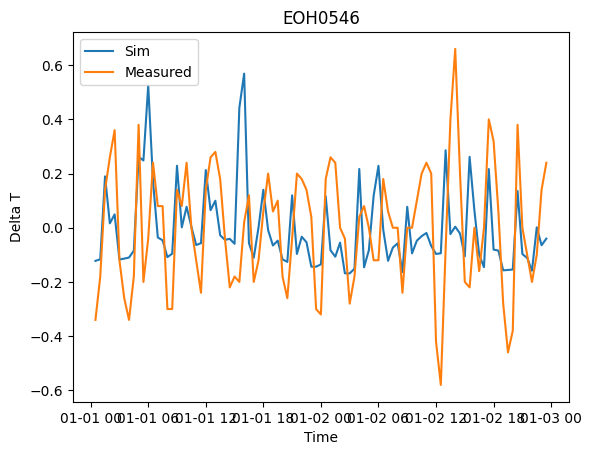

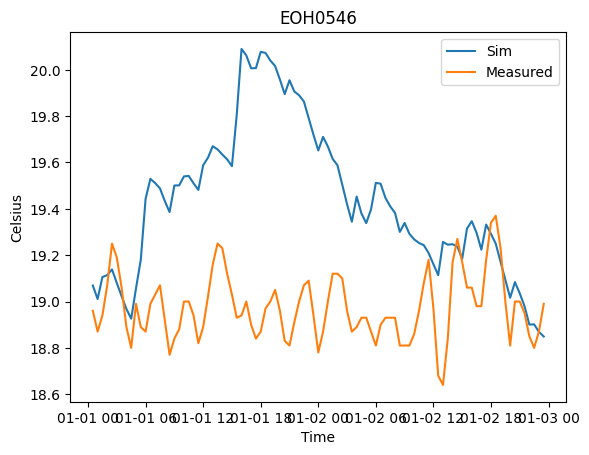

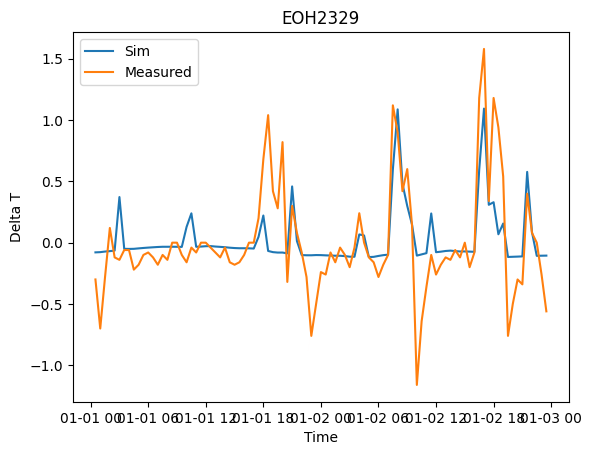

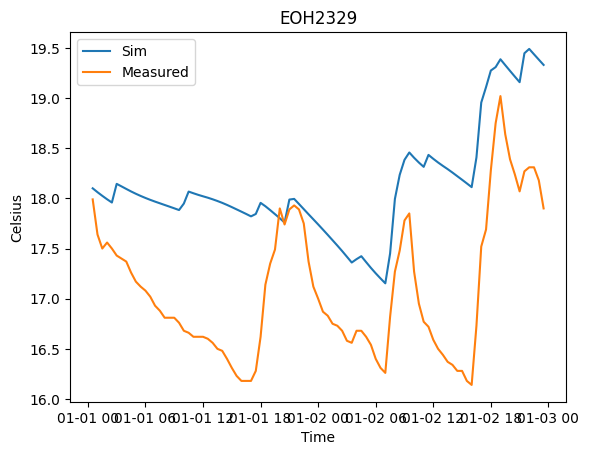

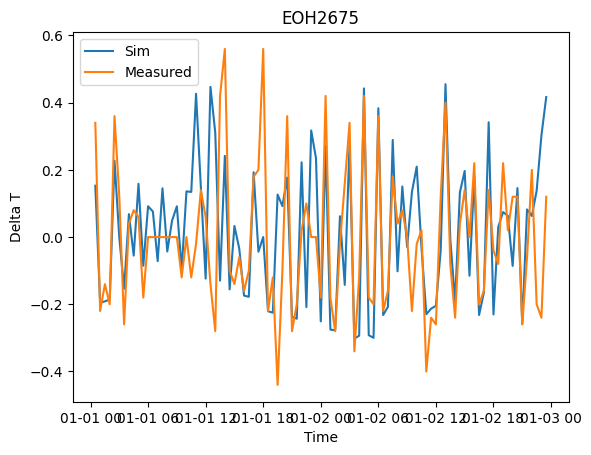

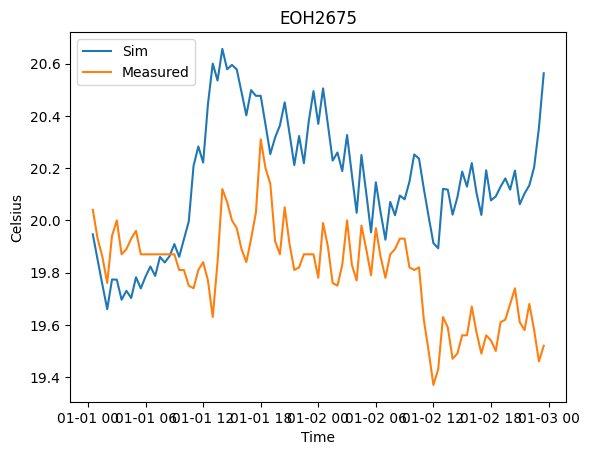

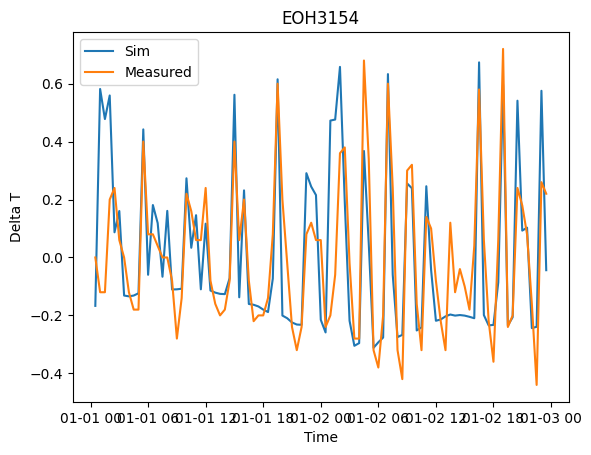

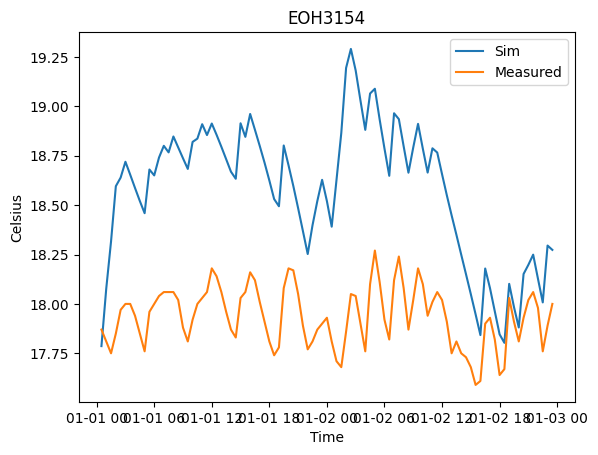

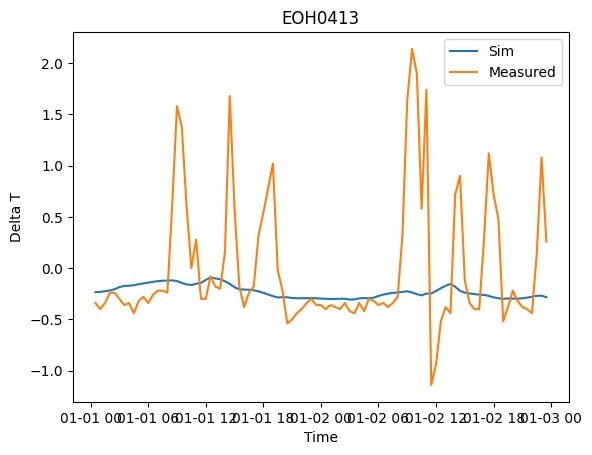

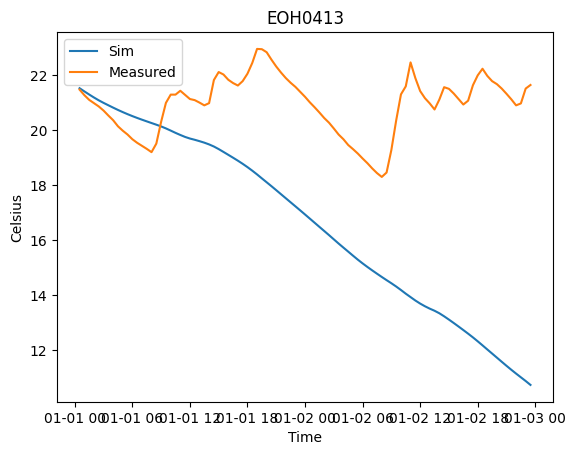

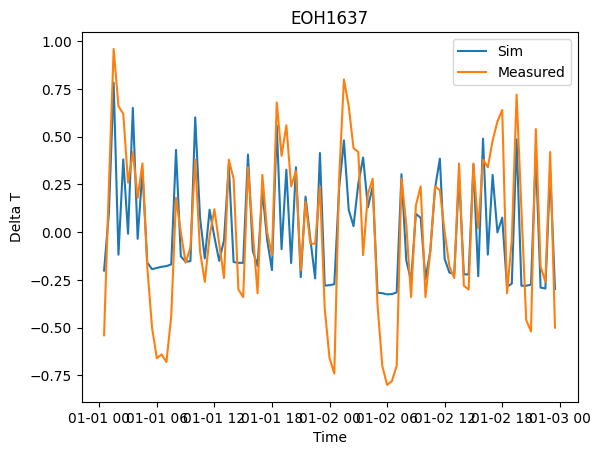

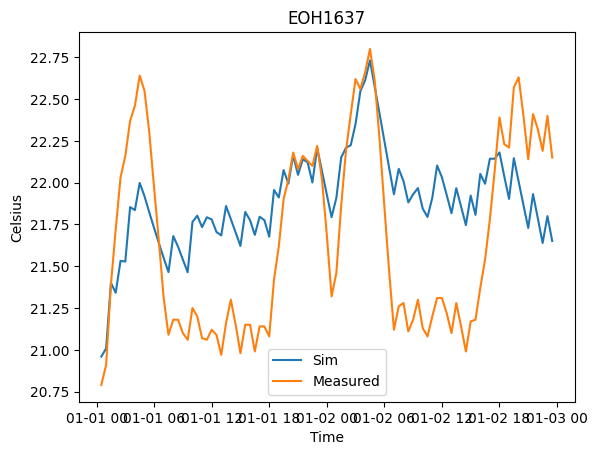

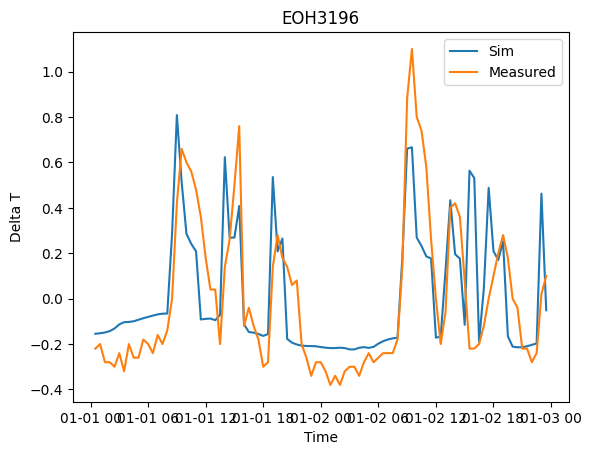

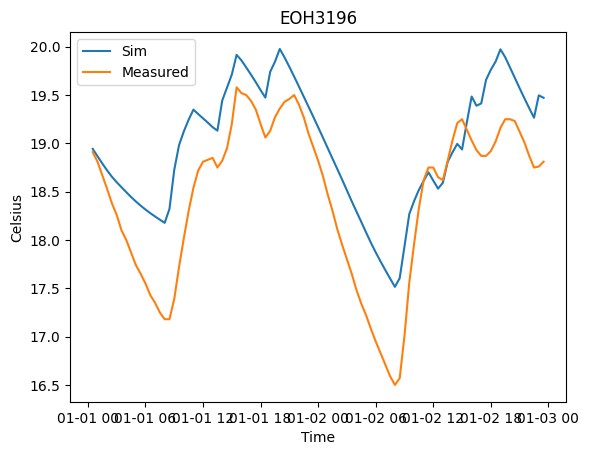

In [27]:
# -----Look at temperature tracking performance in the training --------------

for id_use in unique_ids:
    df_id = trained_params[id_use].copy()
    C = df_id.C
    R_a = df_id.R_a
    w_s= df_id.w_s
    w_n = df_id.w_n
    
    df_single = df_train_detached[df_train_detached["Property_ID"] == id_use].copy()
    
    #re-adjust Heat Pump Diff and add temp differences
    df_single["Heat_Pump_Energy_Output_Diff"] = df_single["Heat_Pump_Energy_Output"].diff()
    df_single["Internal_Temperature_Diff"] = df_single["Internal_Air_Temperature"].diff()
    df_single["Internal_Ambient_Temperature_Diff"] = \
        (df_single["External_Air_Temperature"] - 
         df_single["Internal_Air_Temperature"])
         
    
    
    # 1. Drop columns with almost all missing data (e.g., more than 90% missing)
    threshold = 0.90 * len(df_single)
    df_single_cleaned = df_single.dropna(axis=1, thresh=threshold)
    #print("Columns dropped due to high missing values:")
    #print(df_single.columns.difference(df_single_cleaned.columns).tolist())
    
    df_single = df_single_cleaned
    
    #print("\nColumns remaining after dropping highly missing columns:")
    #print(df_single.columns.tolist())
    
    # 2. Handle missing values: Interpolate if missing for up to 2 hours (4 half-hour intervals), else drop rows
    df_single = df_single.set_index('Timestamp')
    df_single = df_single.sort_index()
    
    # Apply interpolation with a limit of 4 (for 2 hours of half-hourly data)
    numeric_cols = df_single.select_dtypes(include=['number']).columns
    df_single_numeric_interpolated = df_single[numeric_cols].interpolate(method='time', limit=4, limit_direction='both')
    
    df_single_interpolated = df_single.copy() 
    df_single_interpolated[numeric_cols] = df_single_numeric_interpolated
    
    # After interpolation, drop rows that still contain NaN values (meaning they were missing for > 2 hours)
    initial_rows = len(df_single_interpolated)
    df_single_processed = df_single_interpolated.dropna()
    rows_dropped_after_interpolation = initial_rows - len(df_single_processed)
    
    #print(f"\nNumber of rows dropped after handling NA values (missing for >
    # 2 hours): {rows_dropped_after_interpolation}")
    
    # -----EXTRACT SUMMER DATA -------# 
    df_heating_single = df_single_processed.copy()
    
    # Validate results
    t_start = pd.to_datetime("2022 01 01 00:00:00")
    t_end = pd.to_datetime("2022 01 02 23:59:00")
    df_q_id_use = df_q_id[(df_q_id.index>=t_start) & (df_q_id.index<=t_end)]
    df_heating_val = df_heating_single[df_heating_single.index>=t_start]
    df_heating_val = df_heating_val[df_heating_val.index<=t_end]
    
    # make sure you have an Hour column
    df_heating_val = df_heating_val.assign(Hour=df_heating_val.index.hour)
    
    # define night‑time & zero‑solar conditions
    night_time = (df_heating_val['Hour'] >= 22) | (df_heating_val['Hour'] < 6)
    zero_solar = (df_heating_val['SolarRadiation'] == 0)
    
    # vectorized assignment of w
    df_heating_val['w'] = np.where(night_time & zero_solar, w_n, 0.0)
    
    w = df_heating_val['w'].iloc[:-1].reset_index(drop=True).to_numpy()
    
    T_a_val = (df_heating_val["External_Air_Temperature"].iloc[:-1].reset_index
           (drop=True).to_numpy()) 
    T_i_val = (df_heating_val["Internal_Air_Temperature"].iloc[:-1].reset_index
           (drop=True).to_numpy()) 
    delta_T_a_val = (df_heating_val["Internal_Ambient_Temperature_Diff"].iloc[:-1]
                 .reset_index(drop=True).to_numpy()) 
    delta_T_i_val = (df_heating_val["Internal_Temperature_Diff"].iloc[1:]
                 .reset_index(drop=True).to_numpy() / delta_t) 
    q_hp_val = (df_heating_val["Heat_Pump_Energy_Output_Diff"].iloc[:-1]
            .reset_index(drop=True).to_numpy()) 
    q_solar_val = (df_heating_val["SolarRadiation"].iloc[:-1].reset_index
               (drop=True).to_numpy()) 
    v_wind_val = (df_heating_val["Windspeed"].iloc[:-1].reset_index(drop=True)
              .to_numpy()) 
    
    
    delta_T_i_sim = (delta_T_a_val / R_a *delta_t + q_hp_val + w_s* q_solar_val+ w * np
                     .ones(len(T_a_val), )* delta_t) / C
    
    T_i_sim = np.zeros_like(T_i_val)
    T_i_prev = T_i_val[0]
    for i in range(len(delta_T_i_sim)):
        T_i_sim[i] = T_i_prev + delta_T_i_sim[i]*delta_t
        T_i_prev = T_i_sim[i]
    
    
    plt.plot(df_heating_val.index[1:],delta_T_i_sim, label = "Sim")
    plt.plot(df_heating_val.index[1:], delta_T_i_val, label = "Measured")
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Delta T")
    plt.title(f"{id_use}")
    plt.show()
    
    plt.plot(df_heating_val.index[1:],T_i_sim, label = "Sim")
    plt.plot(df_heating_val.index[1:], df_heating_val["Internal_Air_Temperature"]
             .iloc[1:].reset_index
           (drop=True).to_numpy(), label = "Measured")
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Celsius")
    plt.title(f"{id_use}")
    plt.show()